In [1]:
import pm4py
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from collections import Counter
import Functions as fk
import numpy as np

In [2]:
log = xes_importer.apply("/Users/simonimmler/PycharmProjects/Praktikum/data/BPI Challenge 2017.xes")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

# Basic Analytics: 

In [3]:
ts = [e["time:timestamp"] for t in log for e in t if "time:timestamp" in e]
ts = pd.to_datetime(ts, utc=True, errors="coerce")
print("missing ts:", ts.isna().sum())
print("min ts:", ts.min())
print("max ts:", ts.max())


missing ts: 0
min ts: 2016-01-01 09:51:15.304000+00:00
max ts: 2017-02-01 14:11:03.499000+00:00


Different Lifecycle states

In [4]:
lcs = [e.get("lifecycle:transition", "missing") for t in log for e in t]
print(Counter(lcs).most_common(10))

[('complete', 475306), ('suspend', 215402), ('schedule', 149104), ('start', 128227), ('resume', 127160), ('ate_abort', 85224), ('withdraw', 21844)]


In [5]:
df = pm4py.convert_to_dataframe(log)
cols = df["lifecycle:transition"].dropna().unique()
cols

array(['complete', 'schedule', 'withdraw', 'start', 'suspend',
       'ate_abort', 'resume'], dtype=object)

In [6]:
states_per_act = (
    df.groupby("concept:name")["lifecycle:transition"]
      .apply(lambda s: sorted(set(s.dropna())))
      .reset_index(name="lifecycle_states")
)
states_per_act


,concept:name,lifecycle_states
0,A_Accepted,[complete]
1,A_Cancelled,[complete]
2,A_Complete,[complete]
3,A_Concept,[complete]
4,A_Create Application,[complete]
5,A_Denied,[complete]
6,A_Incomplete,[complete]
7,A_Pending,[complete]
8,A_Submitted,[complete]
9,A_Validating,[complete]


Calculate the Event duration for each trace (I use the total span time for each activtiy meaning the total processing time is (timestamp last occurrence in the trace) - (timestamp first occurence in the trace) 

In [7]:
span = (df.dropna(subset=["time:timestamp"]).groupby(["case:concept:name", "concept:name"])["time:timestamp"].agg(act_first_ts="min", act_last_ts="max").reset_index())
span["act_duration_seconds"] = (span["act_last_ts"] - span["act_first_ts"]).dt.total_seconds()

# merge for each Application (case:concept:name) and for each Activity of that case (concept:name)
df_dur = df.merge(span, on=["case:concept:name", "concept:name"], how="left")
df_dur.head(20)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,act_first_ts,act_last_ts,act_duration_seconds
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.304000+00:00,2016-01-01 09:51:15.304000+00:00,0.000
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.352000+00:00,2016-01-01 09:51:15.352000+00:00,0.000
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.413000+00:00,2016-01-01 09:52:36.413000+00:00,0.000
6,Obtained,User_17,W_Complete application,Workflow,Workitem_1875340971,start,2016-01-02 10:45:22.429000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
7,Released,User_17,W_Complete application,Workflow,Workitem_1452291795,suspend,2016-01-02 10:49:28.816000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-02 11:23:04.299000+00:00,2016-01-02 11:23:04.299000+00:00,0.000
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,...,44.0,True,498.29,True,979.0,20000.0,NaN,2016-01-02 11:29:03.994000+00:00,2016-01-02 11:29:03.994000+00:00,0.000


# Processing Times for W_ Activities

Calculate the processing times for all activities, that have more than 1 lifecycle transitions  -> all others have no real working time

In [8]:
seg, proc_inst = fk.build_processing_times(df, workflow_only=False)
proc_inst

,case:concept:name,concept:name,instance,proc_seconds
0,Application_1000086665,W_Call after offers,0,129.277
1,Application_1000086665,W_Complete application,0,642.724
2,Application_1000158214,W_Call after offers,0,115.307
3,Application_1000158214,W_Complete application,0,870.320
4,Application_1000158214,W_Validate application,0,93.137
...,...,...,...,...
127081,Application_999993467,W_Validate application,0,2405.429
127082,Application_999993812,W_Call after offers,0,61.874
127083,Application_999993812,W_Call incomplete files,0,156.698
127084,Application_999993812,W_Complete application,0,447.742


In [9]:
seg

,case:concept:name,concept:name,instance,org:resource,seg_start,seg_end,end_transition,proc_seconds
0,Application_1000086665,W_Call after offers,0,User_5,2016-08-05 14:01:23.286000+00:00,2016-08-05 14:03:01.480000+00:00,suspend,98.194
1,Application_1000086665,W_Call after offers,0,User_18,2016-08-09 18:25:01.546000+00:00,2016-08-09 18:25:32.629000+00:00,suspend,31.083
2,Application_1000086665,W_Complete application,0,User_14,2016-08-04 13:39:29.557000+00:00,2016-08-04 13:50:12.281000+00:00,suspend,642.724
3,Application_1000158214,W_Call after offers,0,User_32,2016-06-06 08:16:46.890000+00:00,2016-06-06 08:18:42.197000+00:00,suspend,115.307
4,Application_1000158214,W_Complete application,0,User_32,2016-06-06 08:02:16.549000+00:00,2016-06-06 08:16:46.869000+00:00,complete,870.320
...,...,...,...,...,...,...,...,...
254365,Application_999993812,W_Call after offers,0,User_18,2016-10-14 08:18:35.150000+00:00,2016-10-14 08:18:57.232000+00:00,suspend,22.082
254366,Application_999993812,W_Call incomplete files,0,User_109,2016-10-19 12:44:29.291000+00:00,2016-10-19 12:44:35.134000+00:00,suspend,5.843
254367,Application_999993812,W_Call incomplete files,0,User_41,2016-10-20 08:19:28.812000+00:00,2016-10-20 08:21:59.667000+00:00,suspend,150.855
254368,Application_999993812,W_Complete application,0,User_104,2016-10-07 09:38:21.802000+00:00,2016-10-07 09:45:49.544000+00:00,suspend,447.742


In [33]:
proc_inst[proc_inst["concept:name"]=="W_Assess potential fraud"]["proc_seconds"].describe()


count       324.000000
mean       8035.435398
std       16924.623661
min           3.903000
25%          92.438500
50%         684.986000
75%        5861.768500
max      122669.588000
Name: proc_seconds, dtype: float64

In [11]:
proc_inst.groupby(["concept:name"])["instance"].max().sort_values(ascending=False).head(20)


concept:name
W_Validate application      8
W_Call incomplete files     6
W_Assess potential fraud    2
W_Call after offers         2
W_Complete application      2
W_Handle leads              2
Name: instance, dtype: int64

In [34]:
durations_full = {}
round_to = 10

for act, g in proc_inst.groupby("concept:name"):
    vals = g["proc_seconds"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vals = np.round(vals, round_to)
    c = Counter(vals.tolist())
    durations_full[act] = [(cnt, val) for val, cnt in c.most_common()]


print("W_ activities in durations_full:", len(durations_full))

W_ activities in durations_full: 6


# O_ and A_ Activities

The event log does not give information about processing times of technical activities, but it would be realistic that there is a little bit of a buffer between those activities

calculate active time for each activity

In [14]:
events = seg["concept:name"].value_counts()
events

concept:name
W_Validate application        72932
W_Call incomplete files       62256
W_Call after offers           60560
W_Complete application        52321
W_Handle leads                 4891
W_Assess potential fraud       1320
W_Shortened completion           81
W_Personal Loan collection        9
Name: count, dtype: int64

In [15]:
events = df["concept:name"].value_counts()
events

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
O_Create Offer                 42995
O_Created                      42995
O_Sent (mail and online)       39707
A_Validating                   38816
A_Create Application           31509
A_Concept                      31509
A_Accepted                     31509
A_Complete                     31362
O_Returned                     23305
A_Incomplete                   23055
O_Cancelled                    20898
A_Submitted                    20423
O_Accepted                     17228
A_Pending                      17228
A_Cancelled                    10431
O_Refused                       4695
A_Denied                        3753
W_Assess potential fraud        3282
O_Sent (online only)            2026
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

# Fit the models

In [35]:
processing_models = {}

for act in durations_full.keys():
    res = fk.select_model_gamma_vs_lognorm(durations_full, act)
    if res is None:
        continue

    if res["best"] == "gamma":
        a, loc, scale = res["gamma"]
        processing_models[act] = {
            "dist": "gamma",
            "params": {"a": float(a), "scale": float(scale)},
            "aic": float(res["aic_gamma"])
        }
    else:
        s, loc, scale = res["lognorm"]
        processing_models[act] = {
            "dist": "lognorm",
            "params": {"s": float(s), "scale": float(scale)},
            "aic": float(res["aic_lognorm"])
        }

print("Built processing models for:", len(processing_models), "activities")


Built processing models for: 6 activities


In [36]:
sorted([(act, m["dist"], m["aic"]) for act, m in processing_models.items()], key=lambda x: x[2])[:15]


[('W_Assess potential fraud', 'lognorm', 5809.132999415391),
 ('W_Handle leads', 'lognorm', 43138.28089291229),
 ('W_Call incomplete files', 'lognorm', 333544.09340686),
 ('W_Call after offers', 'lognorm', 421622.237147297),
 ('W_Complete application', 'gamma', 443762.90717549063),
 ('W_Validate application', 'lognorm', 581503.5849653961)]

In [38]:

all_acts = sorted(set(df["concept:name"]))


for act in all_acts:
    if act not in processing_models:
        processing_models[act] = {"dist": "const", "value": 0.0}  # const times for A_ and O_


In [39]:
import scipy.stats as stats

def sample_processing_time(model, n=1):
    if model["dist"] == "const":
        return [float(model["value"])] * n

    if model["dist"] == "gamma":
        a = model["params"]["a"]
        scale = model["params"]["scale"]
        return list(stats.gamma.rvs(a, loc=0.0, scale=scale, size=n))

    if model["dist"] == "lognorm":
        s = model["params"]["s"]
        scale = model["params"]["scale"]
        return list(stats.lognorm.rvs(s, loc=0.0, scale=scale, size=n))

    raise ValueError("Unknown dist: " + str(model["dist"]))


{'dist': 'lognorm', 'params': {'s': 2.5046280065161732, 'scale': 751.0406837175366}, 'aic': 5809.132999415391}
[np.float64(4121.379449331906), np.float64(38.713091541139015), np.float64(29075.735190613475), np.float64(8020.641365968749), np.float64(86.35894568327917), np.float64(19272.033202725404), np.float64(415.86544606142996), np.float64(3676.5335955115816), np.float64(23.66244282117151), np.float64(92.21646423092761)]


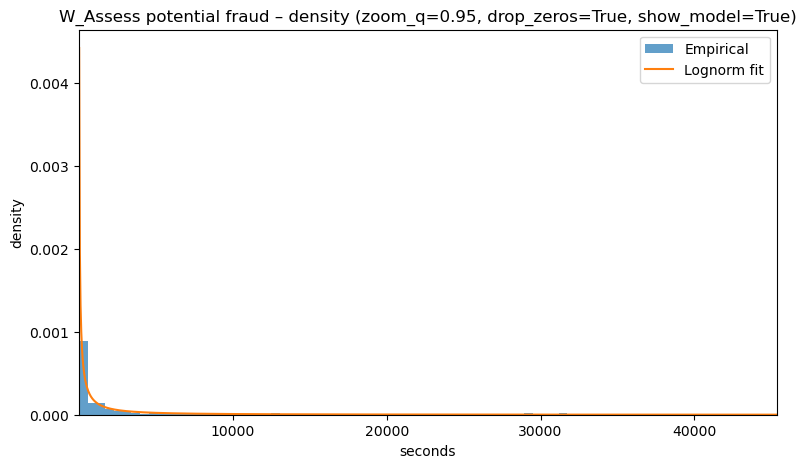

{'dist': 'lognorm', 'params': {'s': 1.0153516971762895, 'scale': 195.14144864234495}, 'aic': 421622.237147297}
[np.float64(1280.9378805465722), np.float64(282.1070086532269), np.float64(329.35952298083123), np.float64(1987.866418906182), np.float64(121.15665427789999), np.float64(350.05894595585363), np.float64(564.0968595798345), np.float64(728.9511679948761), np.float64(307.38224396265394), np.float64(53.43276267982794)]


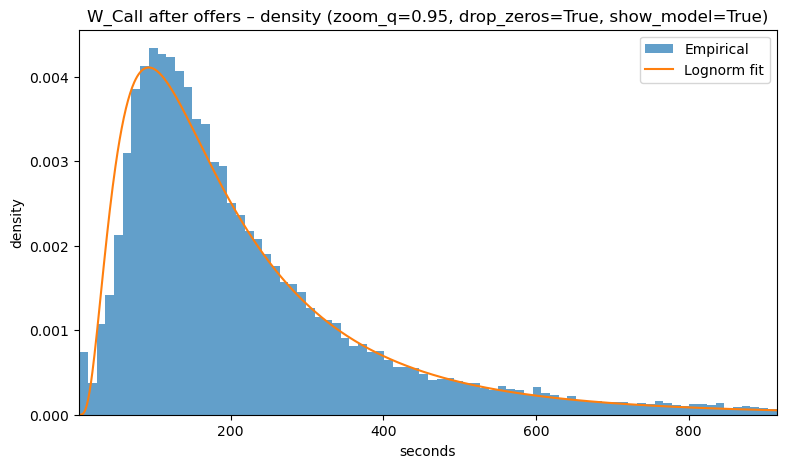

{'dist': 'lognorm', 'params': {'s': 1.1439870559066228, 'scale': 296.8768721250291}, 'aic': 333544.09340686}
[np.float64(182.69791096123987), np.float64(139.7128548503626), np.float64(5181.186001666038), np.float64(190.23931083376033), np.float64(295.6806451595218), np.float64(150.98766551966833), np.float64(1805.1045853840772), np.float64(657.6107024717081), np.float64(198.58586108584652), np.float64(1359.0096454350403)]


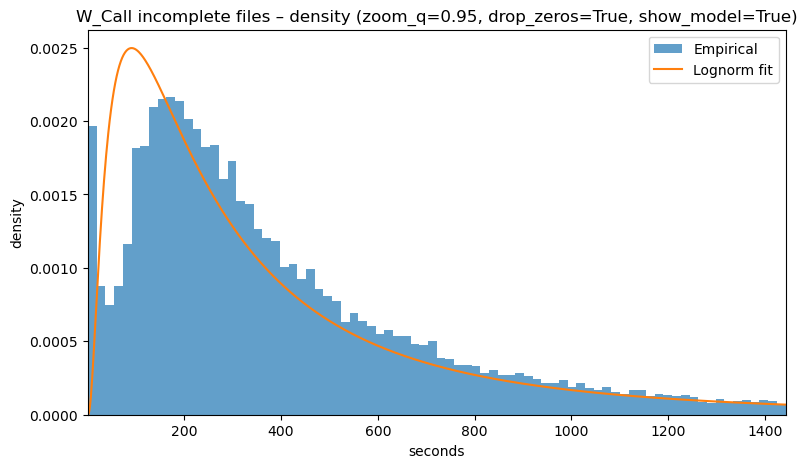

{'dist': 'gamma', 'params': {'a': 1.2032585184726416, 'scale': 546.5540481569567}, 'aic': 443762.90717549063}
[np.float64(81.7368123182735), np.float64(238.8814051685165), np.float64(254.48792962182824), np.float64(373.3161431157773), np.float64(54.993607012103226), np.float64(157.05931566151622), np.float64(1449.6798878279103), np.float64(501.47866030002336), np.float64(358.4709706636131), np.float64(1898.0395024147683)]


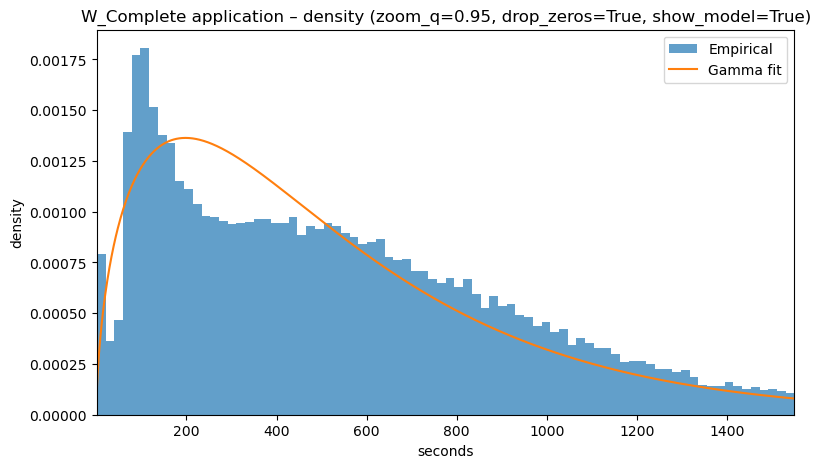

{'dist': 'lognorm', 'params': {'s': 1.095245239765069, 'scale': 82.15583456339792}, 'aic': 43138.28089291229}
[np.float64(53.08200318639065), np.float64(21.77599293266424), np.float64(66.0932229108599), np.float64(51.563270201279444), np.float64(73.7837684748434), np.float64(374.75442921981136), np.float64(1471.6766996964825), np.float64(41.73090393687423), np.float64(59.08002700698882), np.float64(25.98324658886938)]


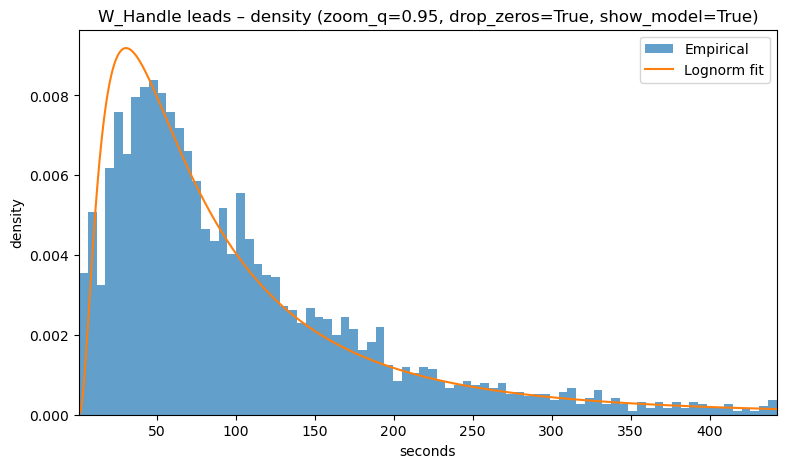

{'dist': 'lognorm', 'params': {'s': 1.7842294530709804, 'scale': 234.03664176563467}, 'aic': 581503.5849653961}
[np.float64(1036.3901308299792), np.float64(548.0963564788645), np.float64(1358.2909686272242), np.float64(12.71940662460194), np.float64(175.88204753908158), np.float64(190.6056658633816), np.float64(1977.608460375015), np.float64(19442.493224767404), np.float64(912.7124608946878), np.float64(521.6641602968982)]


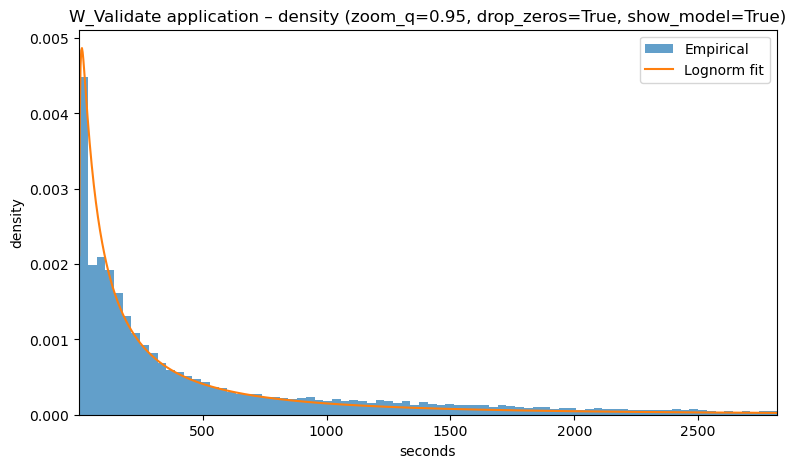

{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Accepted
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Cancelled
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Complete
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Concept
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Create Application
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Denied
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Incomplete
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Pending
{'dist': 'const', 'value': 0.0}
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
No data for A_Submitted
{'dist': 'const', 'value': 0.0}
[0.0

In [40]:
for act in processing_models.keys():
    print(processing_models[act])                 # shows preferred model
    print(sample_processing_time(processing_models[act], n=10))  #  10 samples
    fk.density_plot_from_counts(durations_full, act, show_model=True, dist=processing_models[act]["dist"], drop_zeros=True, zoom_q= 0.95) # plot
    processing_models


In [41]:
import json

with open("processing_models.json", "w") as f:
    json.dump(processing_models, f, indent=2)

print("saved processing_models.json")


saved processing_models.json
